# MP - Clustering

# Estructura del MP

Este laboratorio consiste en 2 partes. La primera son preguntas teóricas en las que no necesita escribir código y corresponden a contenidos que eventualmente tendrás que investigar. La segunda es una sección para evaluar los métodos de clustering.

# Parte 1: Teoría

**1.** Explique cómo k-mean define sus centroides.

>Respuesta: K-Means empieza colocando "centroides" (puntos de referencia) al azar. Luego, agrupa los datos según el centroide que tengan más cerca. Finalmente, recalcula la posición del centroide moviéndolo al promedio (el centro exacto) de todos los datos de ese grupo.

**2.** Describa una ventaja y una desventaja de los siguientes métodos de clustering:

* K-Means
* Clustering Jerárquico Aglomerativo

>Respuesta:
* K-Means: Su ventaja es que es muy rápido y consume poca memoria. Su desventaja es que te obliga a adivinar y definir el número de grupos (k) antes de empezar.

* Jerárquico: Su ventaja es que crea un mapa visual (dendrograma) que te muestra cómo se unen los grupos, sin pedirte el número k. Su desventaja es que es extremadamente pesado y colapsa si tienes miles de datos.

**3.** Evaluar clusters no es una tarea fácil. ¿Qué formas de evaluar clusters conoce? Nombre 3 formas de validación y describa cómo podría determinar si los clusters son buenos o malos usando cada una de las formas nombradas.

>Respuesta:
* Coeficiente Silhouette: Mide si un dato está bien pegado a su grupo y lejos de los demás. Un puntaje cercano a 1 es excelente, cercano a 0 o negativo es malo.

* Método del codo (Inertia/SSE): Mide el error. Buscas en el gráfico el punto donde la línea se dobla como un codo; ahí tienes un buen número de clusters.

* Índice de Davies-Bouldin: Mide la dispersión. Mientras más bajo sea el número, mejor, porque significa que los grupos están compactos y bien separados.

**4.** Explique el enfoque visual para comparar clusters mediante matrices de proximidad. ¿Qué características debe tener la matriz para determinar que una clusterización es buena? ¿En qué casos la matriz de proximidad no es útil para evaluar clustering?

>Respuesta: Es una grilla de colores que compara todos los puntos. Es "buena" si ves cuadrados de color oscuro sólidos y bien definidos en la diagonal principal. No es útil en conjuntos de datos muy grandes porque calcular la distancia entre cada punto contra todos los demás agota la memoria RAM de inmediato.


# Parte 2: Clustering

Para esta parte del Laboratorio vamos a evaluar dos métodos de clustering: `k-means` y `dbscan`. Ejecute las siguientes líneas para descargar y seleccionar los datos.

In [1]:
from sklearn.cluster import DBSCAN
import pandas as pd

dataframe = pd.read_csv("https://gitlab.com/pablo.valenzuela1/datasets/-/raw/main/d31.txt", sep="\t", names = ["V1", "V2"])
X = pd.DataFrame(dataframe).to_numpy()
X

array([[25.0514,  5.7475],
       [26.6614,  7.3414],
       [25.2653,  6.2466],
       ...,
       [ 5.276 , 17.2475],
       [ 6.4444, 16.2033],
       [ 7.162 , 18.1836]])

## K-Means

**1.** Cuando usamos K-Means debemos definir previamente el número de clusters que queremos generar. Teniendo en cuenta estos datos, implemente el método del codo.




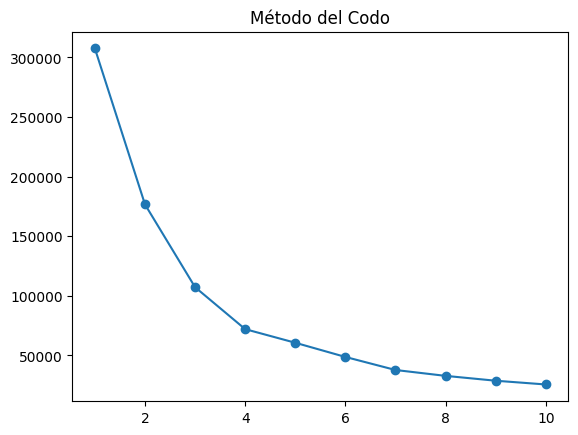

In [2]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

errores = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0).fit(X)
    errores.append(kmeans.inertia_)

plt.plot(range(1, 11), errores, marker='o')
plt.title('Método del Codo')
plt.show()

**2.** ¿Cuántos clusters propone usar para este dataset? Escoja dos opciones y justifique su elección.

> Respuesta: Propongo usar k=3 o k=4. En el gráfico del método del codo, es alrededor del 3 o 4 donde la curva deja de caer drásticamente y comienza a estabilizarse (se forma el "codo").

**3.** Genere un gráfico para cada uno de los dos `k` elegidos para tener una representación visual de los clusters.

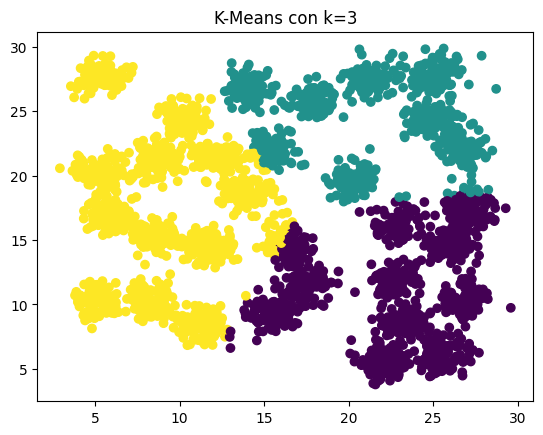

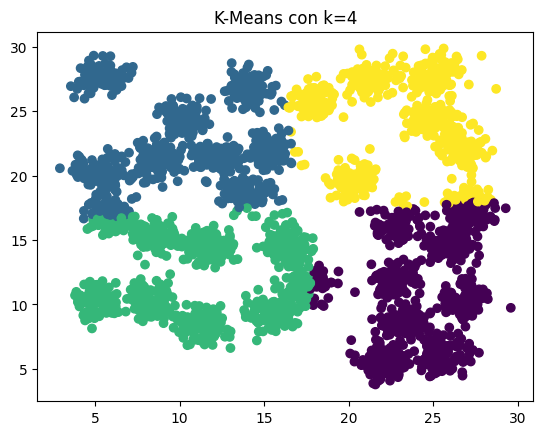

In [3]:
# Graficando para k=3
kmeans3 = KMeans(n_clusters=3, random_state=0).fit(X)
plt.scatter(X[:, 0], X[:, 1], c=kmeans3.labels_)
plt.title('K-Means con k=3')
plt.show()

# Graficando para k=4
kmeans4 = KMeans(n_clusters=4, random_state=0).fit(X)
plt.scatter(X[:, 0], X[:, 1], c=kmeans4.labels_)
plt.title('K-Means con k=4')
plt.show()

## DBSCAN

**1.** Usando los datos anteriores, ejecute DBSCAN y genere un gráfico con los clusters obtenidos. Use los parámetros `eps=0.9`y `min_samples=5`.

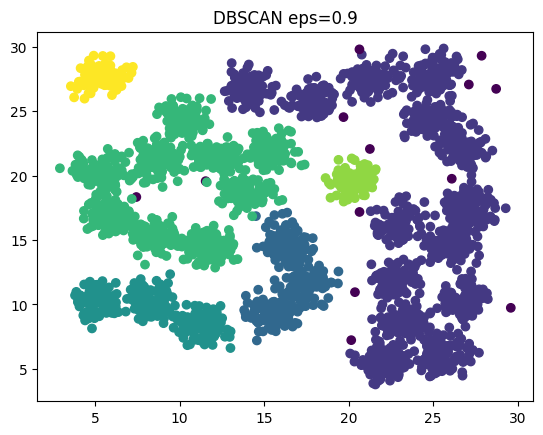

In [4]:
from sklearn.cluster import DBSCAN
dbscan1 = DBSCAN(eps=0.9, min_samples=5).fit(X)
plt.scatter(X[:, 0], X[:, 1], c=dbscan1.labels_)
plt.title('DBSCAN eps=0.9')
plt.show()

**2.** Estime el valor `eps` usando el método de la rodilla (basado en KNN). La idea de este procedimiento es calcular la distancia promedio de cada punto a sus `k` vecinos más cercanos los cuales son graficados en orden ascendente. El objetivo es determinar la *rodilla*, que corresponde al valor óptimo de `eps`. Pruebe varios valores de `y` utilizando el siguiente código y adjunte el gráfico para el mejor `y` que usted considere. Explique por qué escogió el valor `y` como mejor opción.

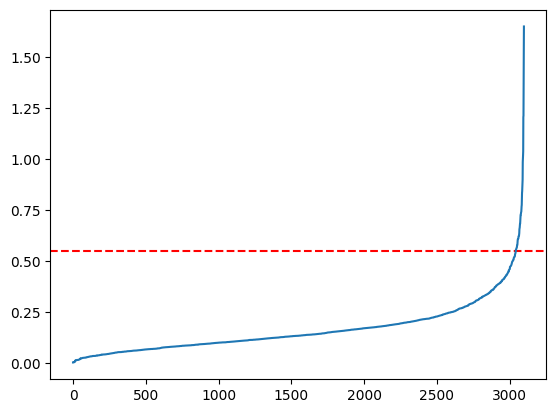

In [27]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

nbrs = NearestNeighbors(n_neighbors=3).fit(X)
distances, indices = nbrs.kneighbors(X)

distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.axhline(y=0.55, color='r', linestyle='--') #Ajuste el valor para y
plt.plot(distances)

**3.**  Ejecute y grafique los clusters usando el método DBSCAN haciendo uso del parámetro `eps` (`y`) encontrado previamente.

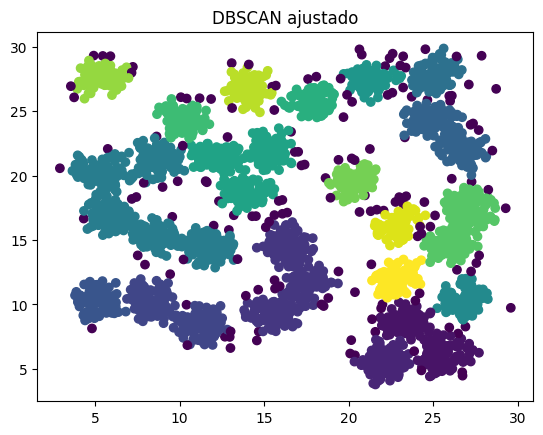

In [25]:
dbscan2 = DBSCAN(eps=0.55, min_samples=5).fit(X)
plt.scatter(X[:, 0], X[:, 1], c=dbscan2.labels_)
plt.title('DBSCAN ajustado')
plt.show()

## Evaluación

**1.** Para evaluar clusters existen una serie de métodos y métricas. Para este laboratorio usaremos el coeficiente de Silhouette. Para cada uno de los experimentos (los dos de la parte de `kmeans` en la pregunta **3** y los dos de la parte de `dbscan` en la pregunta **1** y **3**), adjunte el código que permita obtener el Silhouette score de los modelos.

In [26]:
from sklearn.metrics import silhouette_score
print("Silhouette K=3:", silhouette_score(X, kmeans3.labels_))
print("Silhouette K=4:", silhouette_score(X, kmeans4.labels_))
print("Silhouette DBSCAN 1:", silhouette_score(X, dbscan1.labels_))
print("Silhouette DBSCAN 2:", silhouette_score(X, dbscan2.labels_))

Silhouette K=3: 0.4206646405594788
Silhouette K=4: 0.429505856886424
Silhouette DBSCAN 1: 0.08056489865268891
Silhouette DBSCAN 2: 0.4104688712095814


**2.** En base a los valores del coeficiente de Silhouette obtenidos para cada método y configuración. ¿Cuál cree que es el que tiene mejor resultado? Comente al respecto basándose principalmente en los resultados.

>Respuesta: En base a los coeficientes de Silhouette obtenidos, el modelo que presenta el mejor resultado numérico es K-Means con k=4, ya que obtuvo el puntaje más cercano a 1 (0.4295). Sin embargo, K-Means con k=3 (0.4206) y DBSCAN ajustado con la rodilla (0.4104) lograron resultados muy competitivos y cercanos.
El modelo con peor rendimiento fue DBSCAN con eps=0.9 (0.0805), lo que demuestra la vital importancia de calibrar correctamente el parámetro eps antes de ejecutar el algoritmo. Si bien K-Means (k=4) gana matemáticamente por una fracción mínima, el DBSCAN ajustado sigue siendo una excelente opción para este dataset, ya que ofrece la ventaja adicional de poder identificar y aislar datos anómalos (ruido), algo que K-Means no es capaz de hacer por sí solo.